# Unemployment Analysis with Python

### Oasis Infobyte Data Science Internship - Task 2

**Name:** Srajan Shukla

**Objective:**
The objective of this project is to perform Exploratory Data Analysis (EDA) on India's unemployment dataset to identify regional and temporal trends, analyze the impact of the COVID-19 pandemic on unemployment rates, and visualize important insights using Python.

## Import Required Libraries

In this step, we import all the libraries required for data manipulation, visualization, and analysis throughout the project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

In this step, we load the unemployment dataset into a pandas DataFrame to begin the analysis.

In [2]:
emp1 = pd.read_csv("Unemployment in India.csv")
emp2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [3]:
print("Dataset 1 Shape:", emp1.shape)
print(emp1.columns)

print("\nDataset 2 Shape:", emp2.shape)
print(emp2.columns)

Dataset 1 Shape: (768, 7)
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

Dataset 2 Shape: (267, 9)
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


## Data Inspection

Before performing any analysis, we inspect both datasets to understand their structure, size, and available columns. This helps us determine which dataset is more suitable for further analysis.

In [6]:
print("Dataset 1 Shape:", emp1.shape)
print("Dataset 2 Shape:", emp2.shape)

Dataset 1 Shape: (768, 7)
Dataset 2 Shape: (267, 9)


In [7]:
print("Dataset 1 Columns")
print(emp1.columns)

print("\nDataset 2 Columns")
print(emp2.columns)

Dataset 1 Columns
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

Dataset 2 Columns
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


In [9]:
emp1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [10]:
emp2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## Dataset Information

In this step, we examine the structure of the selected dataset, including data types, missing values, and statistical summary. This helps us understand the quality of the data before performing analysis.

In [11]:
emp1.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [12]:
emp1.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [13]:
emp1.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## Data Cleaning

Before analyzing the dataset, we clean the column names by removing any unnecessary leading or trailing spaces. This makes the column names easier to access and reduces the chances of errors while writing code.

emp1.columns = emp1.columns.str.strip()

## Convert the Date Column

The Date column is stored as text (string). To perform time-based analysis such as monthly trends and pre-COVID vs. post-COVID comparisons, we convert it into the datetime format.

In [18]:
emp1["Date"] = pd.to_datetime(emp1["Date"])

In [19]:
emp1.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 42.1 KB


In [20]:
emp1[emp1["Date"] >= "2020-03-01"]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
10,Andhra Pradesh,2020-03-31,Monthly,4.06,11359660.0,40.66,Rural
11,Andhra Pradesh,2020-04-30,Monthly,16.29,8792827.0,36.03,Rural
12,Andhra Pradesh,2020-05-31,Monthly,14.46,9526902.0,38.16,Rural
13,Andhra Pradesh,2020-06-30,Monthly,0.85,15572975.0,53.76,Rural
23,Assam,2020-03-31,Monthly,3.77,9878742.0,47.05,Rural
...,...,...,...,...,...,...,...
739,Uttarakhand,2020-06-30,Monthly,5.08,989470.0,35.61,Urban
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban


In [24]:
region_avg = emp1.groupby("Region")["Estimated Unemployment Rate (%)"].mean()
region_avg = region_avg.sort_values(ascending=False)
print(region_avg)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


## Top 10 States with Highest Average Unemployment Rate

This visualization displays the top 10 states/regions with the highest average unemployment rate. It helps identify the regions that experienced the greatest unemployment on average during the observed period.

In [23]:
top10 = region_avg.head(10)
print(top10)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


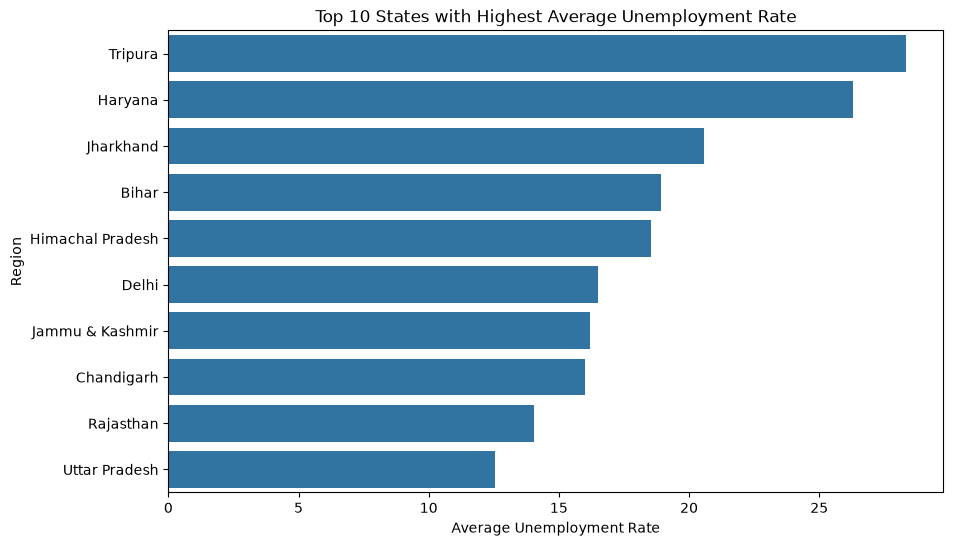

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(x=top10.values,y=top10.index)
plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate")
plt.ylabel("Region")
plt.show()

### Observation

The bar chart shows the ten regions with the highest average unemployment rates. It allows us to quickly identify which regions were most affected during the observed period. These differences suggest that unemployment varied significantly across different states.

## Month-wise Unemployment Trend

In this step, we extract the month from the Date column and calculate the average unemployment rate for each month. This helps us understand how unemployment changed over time.

In [28]:
emp1["Month"] = emp1["Date"].dt.month_name()

In [29]:
emp1[["Date", "Month"]].head()

,Date,Month
0,2019-05-31,May
1,2019-06-30,June
2,2019-07-31,July
3,2019-08-31,August
4,2019-09-30,September


## Average Unemployment Rate by Month

In this step, we calculate the average unemployment rate for each month to identify monthly trends in unemployment.

In [35]:
month_avg = emp1.groupby("Month")["Estimated Unemployment Rate (%)"].mean()
print(month_avg)

Month
April        23.641569
August        9.637925
December      9.497358
February      9.964717
January       9.950755
July          9.033889
June         10.553462
March        10.700577
May          16.646190
November      9.868364
October       9.900909
September     9.051731
Name: Estimated Unemployment Rate (%), dtype: float64


In [36]:
month_order = ["January", "February", "March", "April","May", "June", "July", "August",
               "September", "October", "November", "December"]

In [37]:
emp1["Month"] = pd.Categorical(emp1["Month"],categories=month_order,ordered=True)

In [39]:
month_avg = emp1.groupby("Month")["Estimated Unemployment Rate (%)"].mean()
print(month_avg)

Month
January       9.950755
February      9.964717
March        10.700577
April        23.641569
May          16.646190
June         10.553462
July          9.033889
August        9.637925
September     9.051731
October       9.900909
November      9.868364
December      9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


## Monthly Unemployment Trend

This line chart shows the average unemployment rate for each month. It helps identify changes in unemployment over time and highlights the impact of the COVID-19 pandemic.

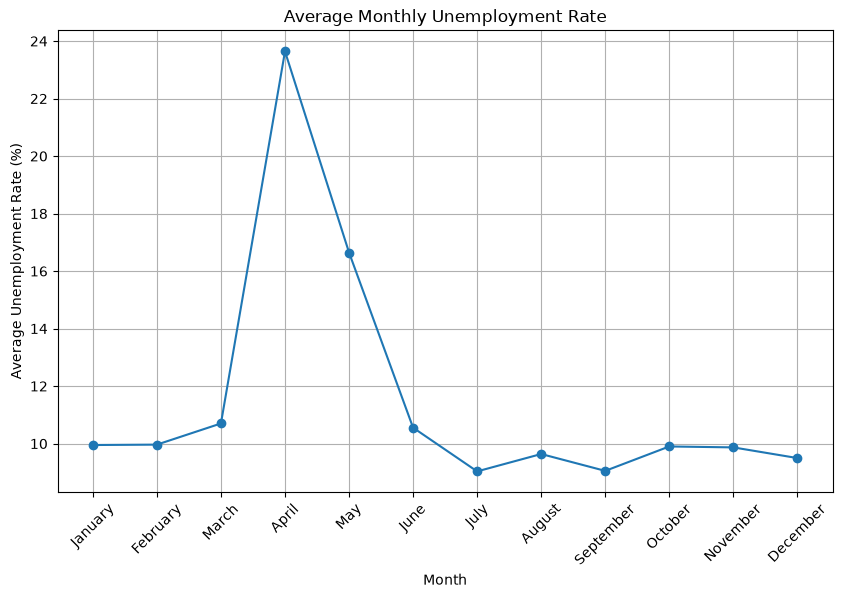

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(month_avg.index,month_avg.values,marker="o")
plt.title("Average Monthly Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation

The line chart shows how the average unemployment rate changed from month to month. A noticeable rise around the COVID-19 lockdown period (March–April 2020) would indicate the pandemic's impact on employment. The chart also helps identify whether unemployment later recovered or remained elevated.

## Time-Series Comparison of Major States

This visualization compares the unemployment rate over time for three major states. It helps identify how unemployment trends differed across regions during the COVID-19 period.

In [41]:
emp1["Region"].unique()

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
                nan,       'Chandigarh']
Length: 29, dtype: str

## Filter Data for Selected States

In this step, we filter the dataset to include only Delhi, Tamil Nadu, and West Bengal. This allows us to compare their unemployment trends over time.

In [47]:
selected_states = ["Delhi","Tamil Nadu","West Bengal"]
state_data = emp1[emp1["Region"].isin(selected_states)]
print(state_data.head())

   Region       Date Frequency  Estimated Unemployment Rate (%)  \
54  Delhi 2019-05-31   Monthly                            12.56   
55  Delhi 2019-06-30   Monthly                             9.33   
56  Delhi 2019-07-31   Monthly                            11.07   
57  Delhi 2019-08-31   Monthly                            17.18   
58  Delhi 2019-09-30   Monthly                            12.50   

    Estimated Employed  Estimated Labour Participation Rate (%)   Area  \
54            169487.0                                    42.33  Rural   
55            149076.0                                    35.74  Rural   
56            166605.0                                    40.53  Rural   
57            135407.0                                    35.21  Rural   
58            166056.0                                    40.68  Rural   

        Month  
54        May  
55       June  
56       July  
57     August  
58  September  


## Time-Series Comparison of Selected States

This line chart compares the unemployment rates of Delhi, Tamil Nadu, and West Bengal over time. It helps us observe how unemployment changed in different states during the COVID-19 period.

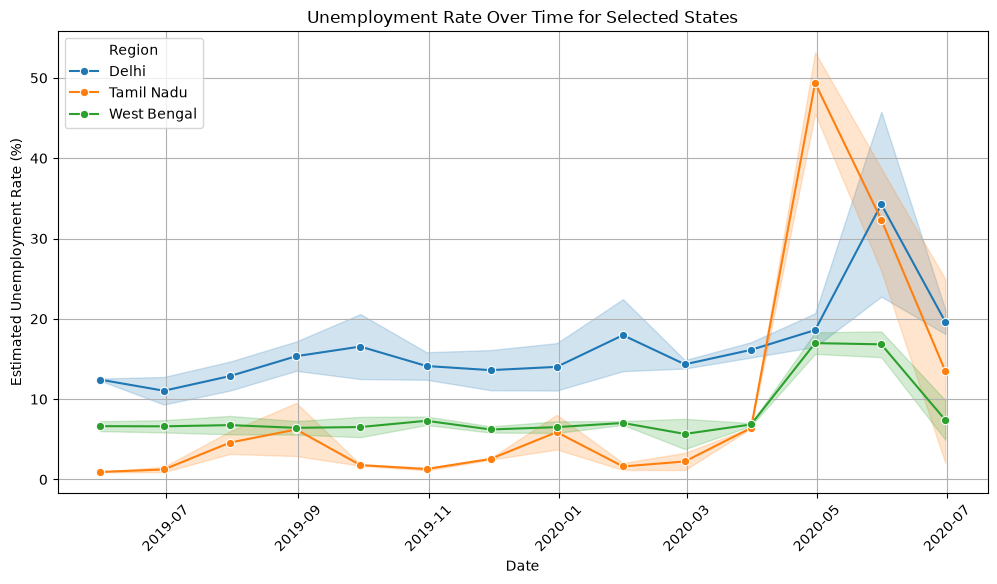

In [48]:
plt.figure(figsize=(12,6))
sns.lineplot(data=state_data,x="Date",y="Estimated Unemployment Rate (%)",hue="Region",
             marker="o")
plt.title("Unemployment Rate Over Time for Selected States")
plt.xlabel("Date")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation

The line chart compares unemployment trends for Delhi, Tamil Nadu, and West Bengal over time. The graph highlights how unemployment changed during the COVID-19 period and allows comparison of fluctuations across different states.

## Correlation Heatmap

This heatmap shows the correlation between unemployment rate, employment, and labour participation rate. It helps identify whether these numerical features are positively or negatively related.

In [49]:
corr_data = emp1[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

### Calculate the Correlation Matrix

The correlation matrix measures the strength and direction of the relationship between numerical variables.

In [50]:
corr_matrix = corr_data.corr()
print(corr_matrix)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


## Correlation Heatmap

The heatmap visually represents the correlation between numerical variables. Darker or stronger colors indicate stronger positive or negative relationships.

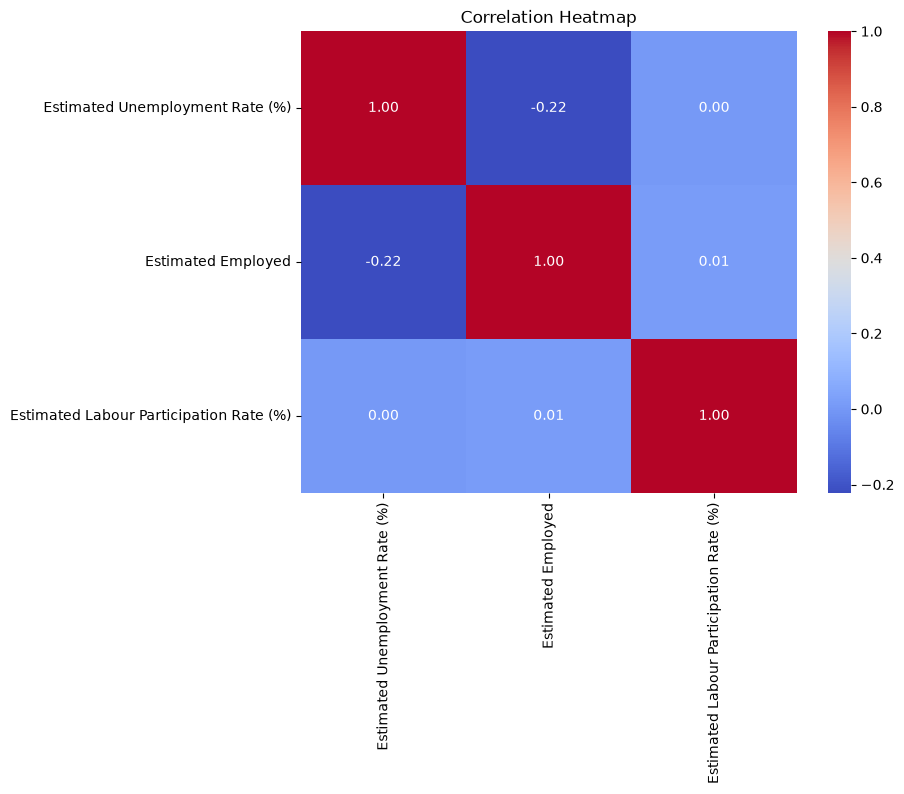

In [51]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Pre-COVID vs Post-COVID Analysis

The COVID-19 pandemic significantly affected employment across India. In this step, we compare the average unemployment rate before and after the COVID-19 lockdown to understand its impact.

In [52]:
pre_covid = emp1[emp1["Date"] < "2020-03-01"]
post_covid = emp1[emp1["Date"] >= "2020-03-01"]
print(pre_covid,post_covid)

             Region       Date Frequency  Estimated Unemployment Rate (%)  \
0    Andhra Pradesh 2019-05-31   Monthly                             3.65   
1    Andhra Pradesh 2019-06-30   Monthly                             3.05   
2    Andhra Pradesh 2019-07-31   Monthly                             3.75   
3    Andhra Pradesh 2019-08-31   Monthly                             3.32   
4    Andhra Pradesh 2019-09-30   Monthly                             5.17   
..              ...        ...       ...                              ...   
745     West Bengal 2019-10-31   Monthly                             7.83   
746     West Bengal 2019-11-30   Monthly                             6.61   
747     West Bengal 2019-12-31   Monthly                             7.24   
748     West Bengal 2020-01-31   Monthly                             7.27   
749     West Bengal 2020-02-29   Monthly                             7.55   

     Estimated Employed  Estimated Labour Participation Rate (%)   Area  \


### Calculate Average Unemployment Rate

Now we calculate the average unemployment rate before and after the COVID-19 outbreak.

In [53]:
pre_avg = pre_covid["Estimated Unemployment Rate (%)"].mean()
post_avg = post_covid["Estimated Unemployment Rate (%)"].mean()
print("Pre-COVID Average:", pre_avg)
print("Post-COVID Average:", post_avg)

Pre-COVID Average: 9.509533582089553
Post-COVID Average: 17.774362745098042


## Visual Comparison of Pre-COVID and Post-COVID

This bar chart compares the average unemployment rate before and after the COVID-19 outbreak.

In [54]:
comparison = pd.DataFrame({"Period": ["Pre-COVID", "Post-COVID"],
                           "Average Unemployment Rate": [pre_avg, post_avg]})
print(comparison)

       Period  Average Unemployment Rate
0   Pre-COVID                   9.509534
1  Post-COVID                  17.774363


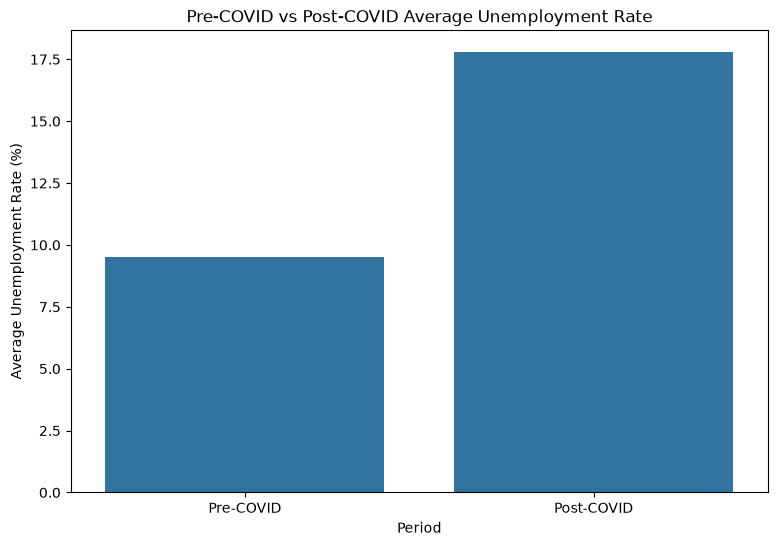

In [55]:
plt.figure(figsize=(9,6))
sns.barplot(data=comparison,x="Period",y="Average Unemployment Rate")
plt.title("Pre-COVID vs Post-COVID Average Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

### Observation

The average unemployment rate after the COVID-19 outbreak is higher than before the outbreak. This suggests that the pandemic had a significant impact on employment in India during the observed period.

# Conclusion

This project analyzed unemployment trends in India using Python. The analysis included data cleaning, exploratory data analysis, visualizations, correlation analysis, and a comparison of unemployment rates before and after the COVID-19 outbreak. The findings indicate that unemployment rates increased during the pandemic, demonstrating its significant impact on employment across different regions.